In [1]:
!pip install webdataset --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.7 MB/s eta 0:00:00


In [ ]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

# Experiment 01 - Baseline CNN

**Goal:** Establish the performance floor with a minimal 2-block CNN, no augmentation.  
**Model:** `BaselineCNN`
**Metric (primary):** Macro-F1 on the held-out test set  
**Augmentation:** None (eval transform only -> resize + normalize)do n  

Results from this notebook define the baseline that all subsequent experiments must beat.

In [ ]:
import torch
from config import load_config
from augmentation import build_eval_transform
from dataset import build_dataloaders
from model import BaselineCNN
from training import Trainer, compute_class_weights
from utils import set_seed, show_results, load_model

cfg = load_config(ROOT / 'configs/config.yaml')
set_seed(cfg.preprocessing.random_seed, cfg.device)
print(f'Device: {cfg.device} | Dataset: {cfg.dataset_variant} | Classes: {len(cfg.classes)}')

In [4]:
EXP_NAME = 'baseline'
num_classes = len(cfg.classes)

# No augmentation for baseline - eval transform on all splits isolates model capacity
eval_tf = build_eval_transform(cfg.preprocessing.image_size, use_imagenet_norm=False)

train_loader, val_loader, test_loader = build_dataloaders(
    train_transform=eval_tf,
    eval_transform=eval_tf,
    **cfg.dataloader_kwargs(),
)
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

  [DEBUG] _build_split_loader: split=train | shards=76 | total=75893 | num_workers=2
  [DEBUG] _build_split_loader: split=val | shards=15 | total=14885 | num_workers=2
  [DEBUG] _build_split_loader: split=test | shards=14 | total=13280 | num_workers=2
Train batches: 592  Val: 117  Test: 104


In [5]:
model = BaselineCNN(in_channels=3, num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'BaselineCNN - Trainable params: {n_params:,}')

BaselineCNN - Trainable params: 155,365


In [ ]:
class_weights = compute_class_weights(cfg.class_weight_source, num_classes) if cfg.training.use_class_weights else None

# Set to path of last.pt to resume, or None to start fresh
RESUME_FROM = None  # e.g. str(cfg.checkpoints_root / EXP_NAME / 'last.pt')

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=cfg.device,
    exp_name=EXP_NAME,
    results_root=cfg.results_root,
    checkpoints_root=cfg.checkpoints_root,
    num_epochs=cfg.training.num_epochs,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    grad_clip=cfg.training.grad_clip,
    grad_accum_steps=cfg.training.grad_accum_steps,
    early_stopping_patience=cfg.training.early_stopping_patience,
    use_amp=cfg.training.use_amp,
    scheduler=cfg.training.scheduler,
    class_weights=class_weights,
    num_classes=num_classes,
    resume_from=RESUME_FROM,
)

history = trainer.train()

Test Loss:      3.5344
Test Accuracy:  0.1067
Test Macro-F1:  0.0754  (primary metric)
Balanced Acc:   0.1071


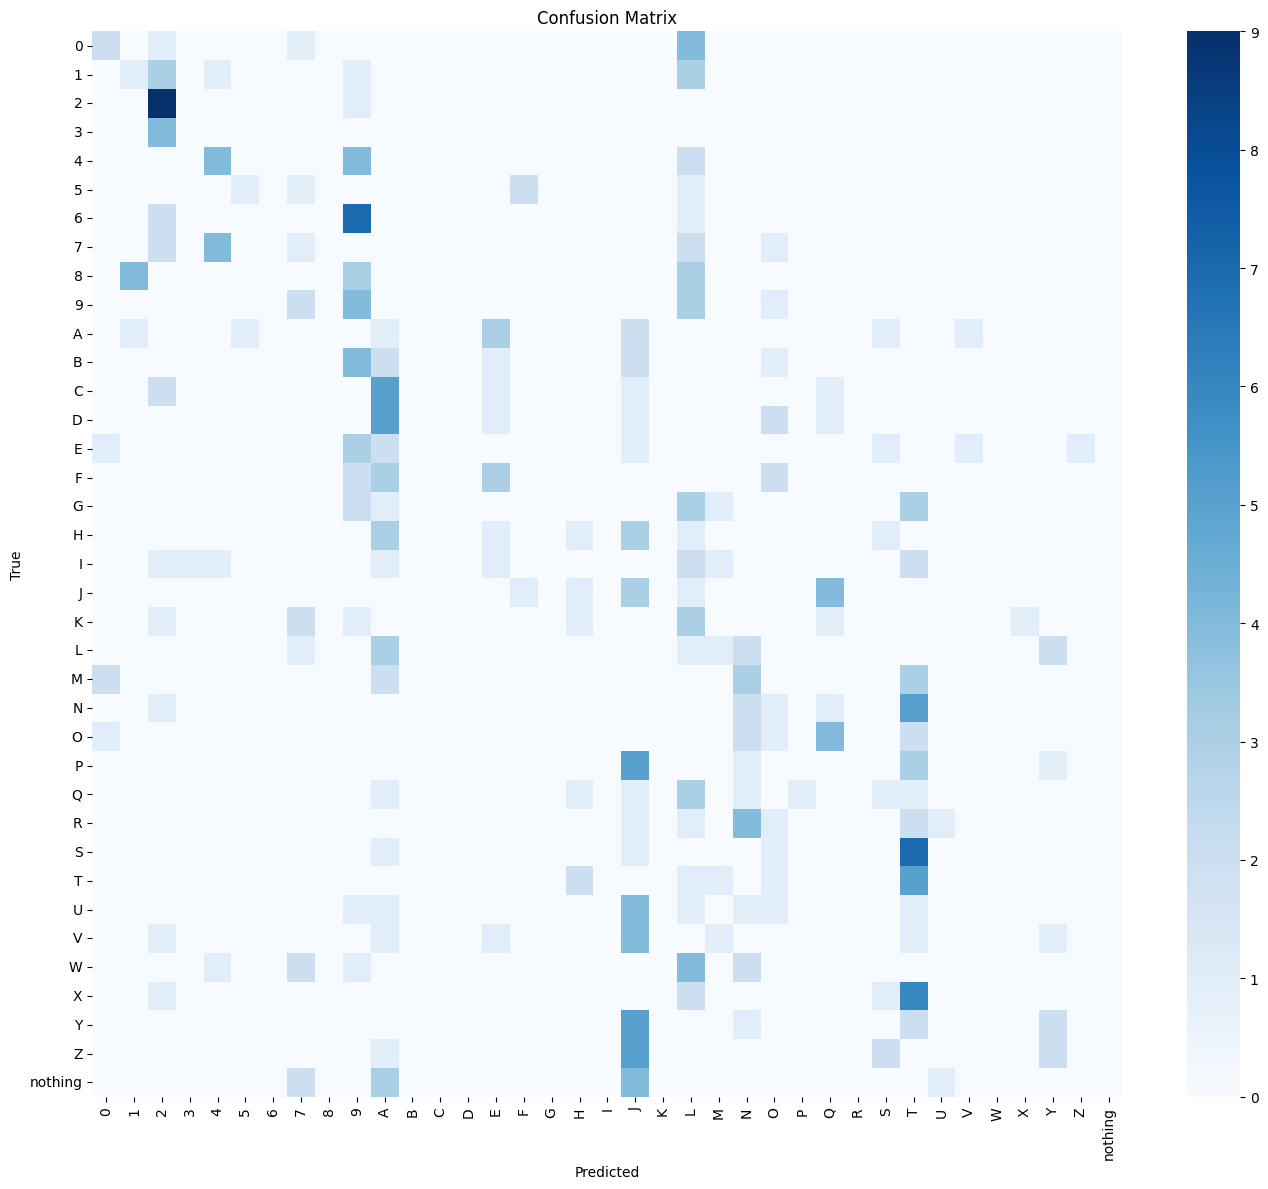

Macro-F1: 0.0754   Balanced Acc: 0.1071

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         8
           1       0.17      0.11      0.13         9
           2       0.32      0.90      0.47        10
           3       0.00      0.00      0.00         4
           4       0.36      0.40      0.38        10
           5       0.50      0.20      0.29         5
           6       0.00      0.00      0.00        10
           7       0.08      0.10      0.09        10
           8       0.00      0.00      0.00        10
           9       0.12      0.40      0.18        10
           A       0.03      0.10      0.04        10
           B       0.00      0.00      0.00        10
           C       0.00      0.00      0.00        10
           D       0.00      0.00      0.00        10
           E       0.00      0.00      0.00        10
           F       0.00      0.00      0.00        10
           G     

In [ ]:
import torch.nn as nn
from utils import evaluate_model

best_ckpt = cfg.checkpoints_root / EXP_NAME / 'best.pt'
model = load_model(BaselineCNN(in_channels=3, num_classes=num_classes), str(best_ckpt), cfg.device)

test_loss, test_acc, test_f1, test_bal, true_labels, pred_labels = evaluate_model(
    model, test_loader, cfg.device, nn.CrossEntropyLoss()
)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Macro-F1: {test_f1:.4f}  (primary metric)')
print(f'Balanced Acc:  {test_bal:.4f}')

show_results(true_labels, pred_labels, cfg.classes, save_dir=str(cfg.results_root / EXP_NAME))

In [ ]:
import json, time
import numpy as np

# Save raw predictions and test summary in the same format as cluster/train.py
results_dir = cfg.results_root / EXP_NAME
np.save(str(results_dir / 'y_true.npy'), np.array(true_labels))
np.save(str(results_dir / 'y_pred.npy'), np.array(pred_labels))

model.eval()
dummy = torch.randn(1, 3, cfg.preprocessing.image_size, cfg.preprocessing.image_size).to(cfg.device)
with torch.no_grad():
    for _ in range(10): model(dummy)
    t0 = time.perf_counter()
    for _ in range(100): model(dummy)
    latency_ms = (time.perf_counter() - t0) / 100 * 1000

num_params_m = sum(p.numel() for p in model.parameters()) / 1e6
total_time_s = sum(history['epoch_time_s'])

test_summary = {
    'exp_name': EXP_NAME,
    'model': 'baseline',
    'test_loss': round(test_loss, 6),
    'test_acc': round(test_acc, 6),
    'test_macro_f1': round(test_f1, 6),
    'test_balanced_acc': round(test_bal, 6),
    'inference_latency_ms': round(latency_ms, 3),
    'num_params_M': round(num_params_m, 2),
    'phase1_epochs': len(history['train_loss']),
    'phase2_epochs': 0,
    'phase1_time_s': round(total_time_s, 1),
    'phase2_time_s': 0.0,
    'total_training_time_s': round(total_time_s, 1),
}
with open(results_dir / 'test_results.json', 'w') as f:
    json.dump(test_summary, f, indent=2)
print(f'Saved y_true.npy, y_pred.npy, test_results.json -> {results_dir}')


In [ ]:
import pandas as pd
hist_csv = cfg.results_root / EXP_NAME / 'history.csv'
if hist_csv.exists():
    df = pd.read_csv(hist_csv)
    display(df[['epoch', 'train_loss', 'val_loss', 'train_macro_f1', 'val_macro_f1', 'val_balanced_acc']])